In [86]:
import numpy as np
import pandas as pd
import glob as gb
import cv2
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score as acc, confusion_matrix, classification_report
import seaborn as sns

np.random.seed(42)

In [87]:
from google.colab import drive
drive.mount('/content/drive')

image_path = gb.glob('/content/drive/MyDrive/Hoda 0-9/*.bmp')
print("number of image:", len(image_path))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
number of image: 544


In [88]:
X, Y = [], []

for path in image_path:
    idx = path.rfind('_') - 1
    label = int(path[idx])

    img = cv2.imread(path, 0)
    img = cv2.resize(img, (10, 10))
    img = img.reshape(100)

    X.append(img)
    Y.append(label)

X = np.array(X, dtype=float)
Y = np.array(Y, dtype=int)
print(X.shape, Y.shape)

(544, 100) (544,)


In [89]:
perm = np.random.permutation(len(X))
X, Y = X[perm], Y[perm]

X = X / 255.0

split = int(0.7 * len(X))
X_train, Y_train = X[:split], Y[:split]
X_val,   Y_val   = X[split:], Y[split:]
print(X_train.shape, X_val.shape)

(380, 100) (164, 100)


In [90]:
def one_hot(y, n_classes=10):
    out = np.zeros((len(y), n_classes))
    out[np.arange(len(y)), y] = 1
    return out

Y_train_oh = one_hot(Y_train)
Y_val_oh   = one_hot(Y_val)

In [91]:
n0, n1, n2, n3 = 100, 32, 16, 10

w1 = np.random.uniform(-1, 1, (n1, n0)) * np.sqrt(1 / n0)
w2 = np.random.uniform(-1, 1, (n2, n1)) * np.sqrt(1 / n1)
w3 = np.random.uniform(-1, 1, (n3, n2)) * np.sqrt(1 / n2)
print(w1.shape, w2.shape, w3.shape)

(32, 100) (16, 32) (10, 16)


In [92]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def softmax(x):
    e = np.exp(x - np.max(x, axis=1, keepdims=True))
    return e / np.sum(e, axis=1, keepdims=True)

def feedforward(X):
    y1 = sigmoid(X @ w1.T)
    y2 = sigmoid(y1 @ w2.T)
    y3 = softmax(y2 @ w3.T)
    return y1, y2, y3

In [93]:
def get_flat_weights():
    return np.concatenate([w1.flatten(), w2.flatten(), w3.flatten()])

def set_flat_weights(flat):
    global w1, w2, w3
    s1, s2, s3 = w1.size, w2.size, w3.size
    w1 = flat[0:s1].reshape(w1.shape)
    w2 = flat[s1:s1+s2].reshape(w2.shape)
    w3 = flat[s1+s2:s1+s2+s3].reshape(w3.shape)

genome_len = get_flat_weights().shape[0]
print("len of chromosome:", genome_len)

len of chromosome: 3872


In [94]:
def cross_entropy(y_true_oh, y_pred, eps=1e-9):
    return -np.mean(np.sum(y_true_oh * np.log(y_pred + eps), axis=1))

def fitness(genome, X, y_oh):
    set_flat_weights(genome)
    _, _, y_pred = feedforward(X)
    loss = cross_entropy(y_oh, y_pred)
    return 1.0 / (1.0 + loss), loss

In [95]:
def tournament_select(fitnesses, k=3):
    idxs = np.random.choice(len(population), k, replace=False)
    best = max(idxs, key=lambda i: fitnesses[i])
    return population[best]

def crossover(p1, p2):
    mask = np.random.rand(genome_len) < 0.5
    return np.where(mask, p1, p2)

def mutate(genome, mutation_rate=0.1, mutation_scale=0.3):
    mask = np.random.rand(genome_len) < mutation_rate
    noise = np.random.randn(genome_len) * mutation_scale
    genome = genome.copy()
    genome[mask] += noise[mask]
    return genome

In [96]:
pop_size = 100
population = [np.random.randn(genome_len) * 0.5 for _ in range(pop_size)]

generations = 600
elite_frac = 0.1
n_elite = max(1, int(pop_size * elite_frac))

patience = 30
best_val_acc = -1
best_val_genome = None
wait = 0

GA_AccTrain, GA_AccVal = [], []

for gen in range(generations):
    fitnesses, losses = [], []
    for genome in population:
        fit, loss = fitness(genome, X_train, Y_train_oh)
        fitnesses.append(fit)
        losses.append(loss)

    order = np.argsort(fitnesses)[::-1]
    best_genome = population[order[0]]

    set_flat_weights(best_genome)
    _, _, pred_train = feedforward(X_train)
    _, _, pred_val   = feedforward(X_val)
    acc_train = acc(Y_train, np.argmax(pred_train, axis=1))
    acc_val   = acc(Y_val,   np.argmax(pred_val, axis=1))

    GA_AccTrain.append(acc_train)
    GA_AccVal.append(acc_val)

    if acc_val > best_val_acc:
        best_val_acc = acc_val
        best_val_genome = best_genome.copy()
        wait = 0
    else:
        wait += 1

    if gen % 10 == 0:
        print(f"Gen {gen:4d}/{generations} | acc_train={acc_train:.4f} | acc_val={acc_val:.4f} | best_val={best_val_acc:.4f}")

    if wait >= patience:
        print(f"\nEarly stopping  in genaration {gen} — {patience} validation accuracy did not improve.")
        break

    new_pop = [population[i] for i in order[:n_elite]]
    while len(new_pop) < pop_size:
        p1 = tournament_select(fitnesses)
        p2 = tournament_select(fitnesses)
        child = mutate(crossover(p1, p2))
        new_pop.append(child)
    population = new_pop

set_flat_weights(best_val_genome)
print("\n best Validation accuracy:", best_val_acc)

Gen    0/600 | acc_train=0.3342 | acc_val=0.2988 | best_val=0.2988
Gen   10/600 | acc_train=0.4658 | acc_val=0.5061 | best_val=0.5061
Gen   20/600 | acc_train=0.6658 | acc_val=0.6402 | best_val=0.6646
Gen   30/600 | acc_train=0.6447 | acc_val=0.7500 | best_val=0.7500
Gen   40/600 | acc_train=0.7368 | acc_val=0.7866 | best_val=0.7927
Gen   50/600 | acc_train=0.7711 | acc_val=0.7927 | best_val=0.8171
Gen   60/600 | acc_train=0.8053 | acc_val=0.8110 | best_val=0.8171
Gen   70/600 | acc_train=0.8237 | acc_val=0.8171 | best_val=0.8171

Early stopping  in genaration 72 — 30 validation accuracy did not improve.

 best Validation accuracy: 0.8170731707317073


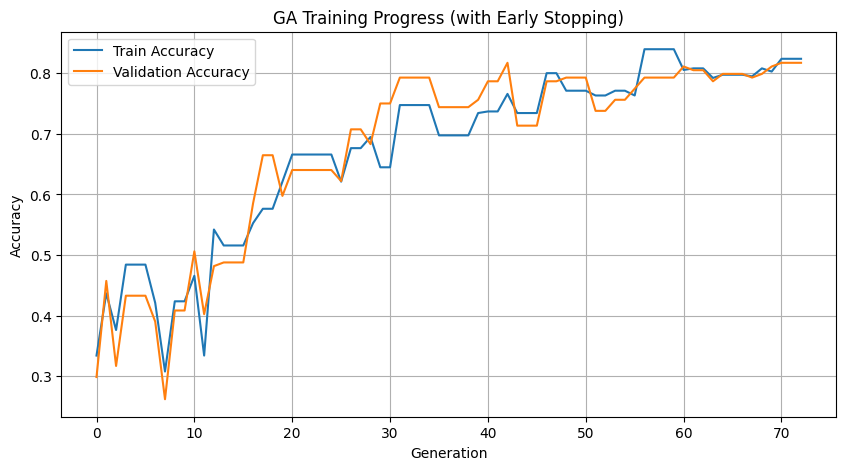

In [97]:
plt.figure(figsize=(10, 5))
plt.plot(GA_AccTrain, label='Train Accuracy')
plt.plot(GA_AccVal, label='Validation Accuracy')
plt.xlabel('Generation')
plt.ylabel('Accuracy')
plt.title('GA Training Progress (with Early Stopping)')
plt.legend()
plt.grid()
plt.show()

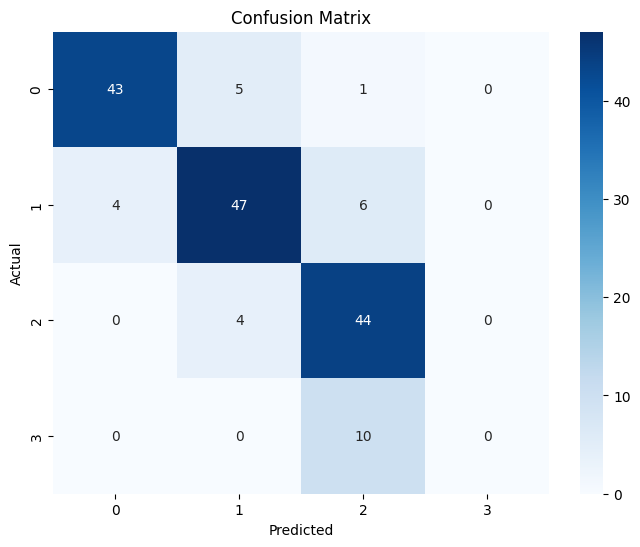

              precision    recall  f1-score   support

           0       0.91      0.88      0.90        49
           1       0.84      0.82      0.83        57
           2       0.72      0.92      0.81        48
           3       0.00      0.00      0.00        10

    accuracy                           0.82       164
   macro avg       0.62      0.65      0.63       164
weighted avg       0.78      0.82      0.79       164



/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [98]:
_, _, pred_val = feedforward(X_val)
Y_pred = np.argmax(pred_val, axis=1)

cm = confusion_matrix(Y_val, Y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

print(classification_report(Y_val, Y_pred))

In [99]:
np.savez("mlp_hoda_ga_weights.npz", w1=w1, w2=w2, w3=w3)
print("The weights were saved.")

The weights were saved.
